# Weighted Bipartite Graph Game Recommender
----------------
**MSc Data Science Dissertation**  
**Author:** Vikrant Deshmukh  
**University:** University of Bristol  
**Project:** Video Game Recommendation System
**MSc Data Science Dissertation**



This is a first-order graph-based similarity model.

Each game is represented as a node connected to feature entities derived from:

- genres;
- categories;
- tags;
- developers; and
- publishers.

The final graph recommender preserves the weighting and similarity logic developed in the exploratory notebook. Its output is standardised for later fusion with metadata and semantic candidates.

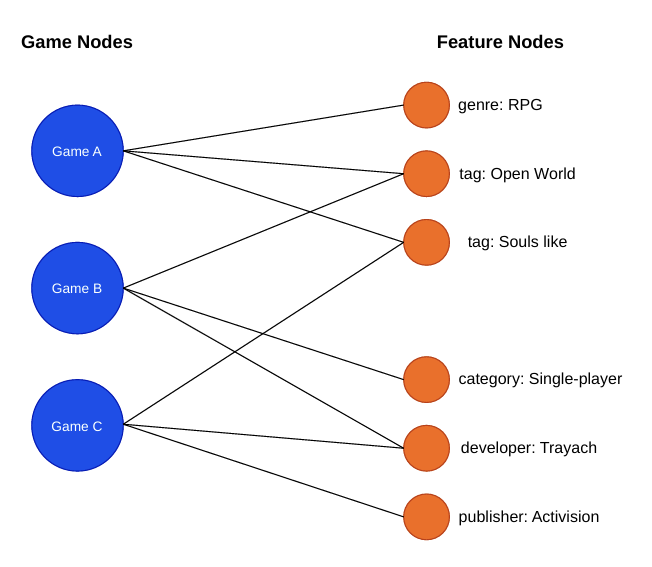

## Notebook Objectives

The notebook aims to:

1. parse list and dictionary-based metadata into consistent feature collections;
2. validate feature coverage across the Steam catalogue;
3. construct a weighted bipartite game-feature graph;
4. represent the graph as a sparse normalised game-feature matrix;
5. retrieve structurally similar games using cosine similarity; and
6. export Top 50 graph candidates for the shared hybrid case studies.

This notebook finalises the existing graph approach rather than introducing a new graph algorithm.

In [2]:
# Core libraries

import ast
import json
import os
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd

from pathlib import Path
from scipy import sparse
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

## 1. Dataset Loading and Intial Inspections

The notebook reuses the cleaned Steam Games Dataset 2025 created during data preparation.

Thus, notebook therefore focuses only on recommendation modelling and does not repeat the complete cleaning pipeline.

In [3]:
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Configure the project and dataset paths.

if IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/MSC_DISSERTATION")
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "Data"
OUTPUT_DIR = PROJECT_ROOT / "Output/graph_outputs"

data_path = DATA_DIR / "games_clean_v1.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

games = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", games.shape)

Dataset loaded successfully.
Dataset shape: (89618, 50)


## 2. Required Column Validation

The graph model uses catalogue identifiers, game titles and structured feature relationships. Engagement fields are retained only for output inspection and later hybrid re-ranking.

In [5]:
required_graph_columns = {
    "appid",
    "name",
    "release_date",
    "genres",
    "categories",
    "tags",
    "developers",
    "publishers",
}

missing_required_columns = sorted(
    required_graph_columns.difference(
        games.columns
    )
)

if missing_required_columns:
    raise KeyError(
        "Missing required graph columns: "
        + ", ".join(
            missing_required_columns
        )
    )

optional_output_columns = [
    "recommendations",
    "positive",
    "negative",
    "num_reviews_total",
    "average_playtime_forever",
    "median_playtime_forever",
    "peak_ccu",
    "metacritic_score",
]

available_optional_columns = [
    column
    for column in optional_output_columns
    if column in games.columns
]

graph_columns = [
    "appid",
    "name",
    "release_date",
    "genres",
    "categories",
    "tags",
    "developers",
    "publishers",
] + available_optional_columns

graph_games = (
    games[graph_columns]
    .copy()
    .reset_index(drop=True)
)

print(
    "Graph columns:",
    graph_columns,
)

print(
    "Graph dataset shape:",
    graph_games.shape,
)

print(
    "Available optional output columns:",
    available_optional_columns,
)


Graph columns: ['appid', 'name', 'release_date', 'genres', 'categories', 'tags', 'developers', 'publishers', 'recommendations', 'positive', 'negative', 'num_reviews_total', 'average_playtime_forever', 'median_playtime_forever', 'peak_ccu', 'metacritic_score']
Graph dataset shape: (89618, 16)
Available optional output columns: ['recommendations', 'positive', 'negative', 'num_reviews_total', 'average_playtime_forever', 'median_playtime_forever', 'peak_ccu', 'metacritic_score']


## 4. Game-Title Normalisation

Titles are used for catalogue lookup only. Normalisation handles punctuation, trademark symbols, apostrophes and capitalisation consistently across all recommender notebooks.

In [6]:
def normalise_game_title(title):
    """Return a stable lookup key for a game title."""

    title = unicodedata.normalize(
        "NFKD",
        str(title),
    )

    title = title.casefold()

    title = (
        title
        .replace("’", "'")
        .replace("‘", "'")
        .replace("`", "'")
        .replace("®", "")
        .replace("™", "")
    )

    title = re.sub(
        r"[^a-z0-9]+",
        " ",
        title,
    )

    return re.sub(
        r"\s+",
        " ",
        title,
    ).strip()


graph_games[
    "normalised_game_title_graph"
] = (
    graph_games["name"]
    .apply(
        normalise_game_title
    )
)

graph_games[
    [
        "name",
        "normalised_game_title_graph",
    ]
].head(10)

,name,normalised_game_title_graph
0,Counter-Strike 2,counter strike 2
1,PUBG: BATTLEGROUNDS,pubg battlegrounds
2,Dota 2,dota 2
3,Grand Theft Auto V Legacy,grand theft auto v legacy
4,Tom Clancy's Rainbow Six® Siege,tom clancy s rainbow six siege
5,Team Fortress 2,team fortress 2
6,Terraria,terraria
7,Rust,rust
8,Garry's Mod,garry s mod
9,Apex Legends™,apex legendstm


## 5. Metadata Parsing

CSV metadata may contain Python-style list strings, delimited strings, dictionaries, existing Python collections or missing values.

Genres, categories, developers and publishers are parsed into clean lists. Tags are parsed from Steam vote dictionaries into tag names. The final graph scoring remains consistent with the original approach: tag presence is used as the graph relation, while relation-type weights and inverse feature frequency determine edge strength.

In [7]:
def normalise_graph_feature(value):
    """Return a canonical graph feature label."""

    value = str(value).strip().casefold()

    value = (
        value
        .replace("’", "'")
        .replace("‘", "'")
        .replace("`", "'")
        .replace("®", "")
        .replace("™", "")
    )

    value = re.sub(
        r"\s+",
        " ",
        value,
    )

    return value.strip()

In [8]:
def parse_list_features(value):
    """Convert a stored list representation into a clean Python list."""

    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(
        value,
        (list, tuple, set),
    ):
        items = list(value)

    else:
        text = str(value).strip()

        if text.casefold() in {
            "",
            "[]",
            "nan",
            "none",
            "null",
        }:
            return []

        try:
            parsed_value = ast.literal_eval(text)



            if isinstance(
                parsed_value,
                (list, tuple, set),
            ):
                items = list(
                    parsed_value
                )
            else:
                items = [
                    parsed_value
                ]

        except (
            ValueError,
            SyntaxError,
        ):
            items = re.split(
                r"[,;|]",
                text,
            )

    cleaned_items = {
        normalise_graph_feature(
            item
        )
        for item in items
        if str(item).strip()
    }

    return sorted(
        item
        for item in cleaned_items
        if item
    )

In [9]:
def parse_tag_dictionary(value):
    """Convert a stored Steam tag dictionary into a clean dictionary."""

    if value is None:
        return {}

    if isinstance(value, float) and pd.isna(value):
        return {}

    if isinstance(value, dict):
        parsed_tags = value

    else:
        text = str(value).strip()

        if text.casefold() in {
            "",
            "{}",
            "nan",
            "none",
            "null",
        }:
            return {}

        try:
            parsed_tags = ast.literal_eval(
                text
            )
        except (
            ValueError,
            SyntaxError,
        ):
            return {}

    if not isinstance(
        parsed_tags,
        dict,
    ):
        return {}

    cleaned_tags = {}

    for tag, vote_count in parsed_tags.items():
        tag_name = normalise_graph_feature(
            tag
        )

        try:
            vote_count = float(
                vote_count
            )
        except (
            TypeError,
            ValueError,
        ):
            vote_count = 0.0

        if tag_name:
            cleaned_tags[tag_name] = max(
                vote_count,
                0.0,
            )

    return cleaned_tags

In [10]:
# now, parsing out each metadata candidates

graph_games["genre_list"] = (
    graph_games["genres"]
    .apply(
        parse_list_features
    )
)

graph_games["category_list"] = (
    graph_games["categories"]
    .apply(
        parse_list_features
    )
)

graph_games["developer_list"] = (
    graph_games["developers"]
    .apply(
        parse_list_features
    )
)

graph_games["publisher_list"] = (
    graph_games["publishers"]
    .apply(
        parse_list_features
    )
)

graph_games["tag_vote_dict"] = (
    graph_games["tags"]
    .apply(
        parse_tag_dictionary
    )
)

graph_games["tag_list"] = (
    graph_games["tag_vote_dict"]
    .apply(
        lambda tag_dict: sorted(
            tag_dict.keys()
        )
    )
)

parsed_columns = [
    "name",
    "genre_list",
    "category_list",
    "tag_list",
    "developer_list",
    "publisher_list",
]

display(
    graph_games[
        parsed_columns
    ]
    .head(5)
)

,name,genre_list,category_list,tag_list,developer_list,publisher_list
0,Counter-Strike 2,"[action, free to play]","[cross-platform multiplayer, in-app purchases, multi-player, remote play on phone, remote play on tablet, remote pla...","[action, co-op, competitive, difficult, e-sports, fast-paced, first-person, fps, military, moddable, multiplayer, on...",[valve],[valve]
1,PUBG: BATTLEGROUNDS,"[action, adventure, free to play, massively multiplayer]","[multi-player, online pvp, pvp, remote play on phone, remote play on tablet, stats]","[action, battle royale, co-op, competitive, difficult, early access, first-person, fps, multiplayer, online co-op, p...",[pubg corporation],"[krafton, inc.]"
2,Dota 2,"[action, free to play, strategy]","[co-op, in-app purchases, multi-player, steam timeline, steam trading cards, steam workshop, steamvr collectibles, v...","[action, action rpg, character customization, co-op, competitive, difficult, e-sports, fantasy, free to play, moba, ...",[valve],[valve]
3,Grand Theft Auto V Legacy,"[action, adventure]","[co-op, full controller support, multi-player, online co-op, online pvp, pvp, remote play on phone, remote play on t...","[action, adventure, atmospheric, automobile sim, co-op, comedy, crime, first-person, funny, great soundtrack, mature...",[rockstar north],[rockstar games]
4,Tom Clancy's Rainbow Six® Siege,[action],"[co-op, full controller support, in-app purchases, multi-player, online co-op, online pvp, pvp, remote play on phone...","[3d, action, co-op, competitive, destruction, difficult, e-sports, first-person, fps, hero shooter, military, multip...",[ubisoft montreal],[ubisoft]


## 6. Parsed Feature Coverage

Coverage is measured before graph construction to show how much of the catalogue can contribute through each relation type.

In [13]:
parsed_feature_columns = {
    "Genres": "genre_list",
    "Categories": "category_list",
    "Tags": "tag_list",
    "Developers": "developer_list",
    "Publishers": "publisher_list",
}

feature_summary_records = []

for feature_name, column_name in (
    parsed_feature_columns.items()
):
    games_with_feature = (
        graph_games[column_name]
        .str.len()
        .gt(0)
        .sum()
    )

    unique_entities = (
        graph_games[column_name]
        .explode()
        .dropna()
        .nunique()
    )

    feature_summary_records.append(
        {
            "feature_type": feature_name,
            "games_with_features": int(
                games_with_feature
            ),
            "coverage_percentage": round(
                100
                * games_with_feature
                / len(graph_games),
                2,
            ),
            "unique_entities": int(
                unique_entities
            ),
        }
    )

feature_summary = pd.DataFrame(
    feature_summary_records
)

display(
    feature_summary
)

,feature_type,games_with_features,coverage_percentage,unique_entities
0,Genres,89406,99.76,33
1,Categories,88742,99.02,40
2,Tags,72746,81.17,452
3,Developers,89397,99.75,59604
4,Publishers,89065,99.38,49488


## 7. Weighted Graph Edge Construction

The current graph model uses the following fixed relation-type weights:

- tags: `1.00`;
- genres: `0.80`;
- categories: `0.60`;
- developers: `0.40`; and
- publishers: `0.30`.

Each row in the edge table represents one game-feature relationship. Duplicate relationships are removed. Features connected to only one game are excluded because they cannot create similarity between two different games.



In [14]:
# defining metadata features
graph_feature_config = {
    "genre": {
        "column": "genre_list",
        "relation_weight": 0.80,
    },
    "category": {
        "column": "category_list",
        "relation_weight": 0.60,
    },
    "tag": {
        "column": "tag_list",
        "relation_weight": 1.00,
    },
    "developer": {
        "column": "developer_list",
        "relation_weight": 0.40,
    },
    "publisher": {
        "column": "publisher_list",
        "relation_weight": 0.30,
    },
}

graph_feature_config

{'genre': {'column': 'genre_list', 'relation_weight': 0.8},
 'category': {'column': 'category_list', 'relation_weight': 0.6},
 'tag': {'column': 'tag_list', 'relation_weight': 1.0},
 'developer': {'column': 'developer_list', 'relation_weight': 0.4},
 'publisher': {'column': 'publisher_list', 'relation_weight': 0.3}}

In [21]:
graph_games = (
    graph_games
    .reset_index(drop=True)
)

graph_games["game_index"] = np.arange(
    len(graph_games)
)

print(
    "Total games:",
    len(graph_games),
)

print(
    "Unique app IDs:",
    graph_games["appid"].nunique(),
)

print(
    "Duplicated app IDs:",
    graph_games["appid"]
    .duplicated()
    .sum(),
)

Total games: 89618
Unique app IDs: 89618
Duplicated app IDs: 0


In [22]:
edge_tables = []

for feature_type, config in (
    graph_feature_config.items()
):
    column_name = config[
        "column"
    ]

    relation_weight = config[
        "relation_weight"
    ]

    feature_edges = (
        graph_games[
            [
                "game_index",
                "appid",
                "name",
                column_name,
            ]
        ]
        .explode(
            column_name
        )
        .dropna(
            subset=[
                column_name
            ]
        )
        .rename(
            columns={
                column_name: "entity"
            }
        )
    )

    feature_edges = feature_edges[
        feature_edges["entity"]
        .astype(str)
        .str.strip()
        .ne("")
    ].copy()

    feature_edges[
        "feature_type"
    ] = feature_type

    feature_edges[
        "relation_weight"
    ] = relation_weight

    feature_edges = (
        feature_edges
        .drop_duplicates(
            subset=[
                "game_index",
                "feature_type",
                "entity",
            ]
        )
    )

    edge_tables.append(
        feature_edges
    )

if not edge_tables:
    raise ValueError(
        "No graph edge tables were created."
    )

graph_edges = pd.concat(
    edge_tables,
    ignore_index=True,
)

print(
    "Total raw game-feature edges:",
    len(graph_edges),
)

Total raw game-feature edges: 1833397


In [23]:
# sanity check
graph_edges.loc[graph_edges["name"] == "Grand Theft Auto V Enhanced"]

,game_index,appid,name,entity,feature_type,relation_weight
2313,825,3240220,Grand Theft Auto V Enhanced,action,genre,0.8
2314,825,3240220,Grand Theft Auto V Enhanced,adventure,genre,0.8
2315,825,3240220,Grand Theft Auto V Enhanced,racing,genre,0.8
265106,825,3240220,Grand Theft Auto V Enhanced,co-op,category,0.6
265107,825,3240220,Grand Theft Auto V Enhanced,in-app purchases,category,0.6
265108,825,3240220,Grand Theft Auto V Enhanced,multi-player,category,0.6
265109,825,3240220,Grand Theft Auto V Enhanced,online co-op,category,0.6
265110,825,3240220,Grand Theft Auto V Enhanced,online pvp,category,0.6
265111,825,3240220,Grand Theft Auto V Enhanced,partial controller support,category,0.6
265112,825,3240220,Grand Theft Auto V Enhanced,pvp,category,0.6


## 8. Entity Frequency Filtering and Edge Weighting

After constructing the raw game-feature edge table, each feature entity is evaluated according to how many distinct games it connects to.

Feature entities that occur in only one game are removed because they cannot contribute to pairwise game similarity. The remaining entities are weighted using an inverse-frequency term so that highly common features contribute less strongly, while less common and potentially more informative features receive greater emphasis.

For each retained entity, the inverse-frequency weight is calculated as:

$$
\text{IDF}(e) = 1 + \log\left(\frac{N+1}{df_e+1}\right)
$$

where \(N\) is the total number of games and \(df_e\) is the number of distinct games connected to entity \(e\).

The final graph edge weight combines this inverse-frequency component with the predefined importance of the corresponding relation type:

$$
w(g,e) = w_{\text{relation}} \times \text{IDF}(e)
$$

This weighting scheme therefore accounts for both the semantic importance of each relation type and the discriminative value of individual feature entities.
.

In [24]:
entity_frequencies = (
    graph_edges
    .groupby(
        [
            "feature_type",
            "entity",
        ]
    )["game_index"]
    .nunique()
    .reset_index(
        name="game_count"
    )
)

graph_edges = graph_edges.merge(
    entity_frequencies,
    on=[
        "feature_type",
        "entity",
    ],
    how="left",
)

raw_edge_count = len(
    graph_edges
)

graph_edges = (
    graph_edges[
        graph_edges[
            "game_count"
        ]
        .ge(2)
    ]
    .copy()
    .reset_index(drop=True)
)

removed_singleton_edges = (
    raw_edge_count
    - len(graph_edges)
)

total_games = len(
    graph_games
)

graph_edges[
    "idf_weight"
] = (
    np.log(
        (total_games + 1)
        / (
            graph_edges[
                "game_count"
            ]
            + 1
        )
    )
    + 1
)

graph_edges[
    "edge_weight"
] = (
    graph_edges[
        "relation_weight"
    ]
    * graph_edges[
        "idf_weight"
    ]
)

print(
    "Edges before singleton removal:",
    raw_edge_count,
)

print(
    "Edges after singleton removal:",
    len(graph_edges),
)

print(
    "Removed singleton edges:",
    removed_singleton_edges,
)

display(
    graph_edges[
        [
            "name",
            "feature_type",
            "entity",
            "game_count",
            "relation_weight",
            "idf_weight",
            "edge_weight",
        ]
    ]
    .head(10)
)

Edges before singleton removal: 1833397
Edges after singleton removal: 1749653
Removed singleton edges: 83744


,name,feature_type,entity,game_count,relation_weight,idf_weight,edge_weight
0,Counter-Strike 2,genre,action,36842,0.8,1.888902,1.511121
1,Counter-Strike 2,genre,free to play,8867,0.8,3.313118,2.650494
2,PUBG: BATTLEGROUNDS,genre,action,36842,0.8,1.888902,1.511121
3,PUBG: BATTLEGROUNDS,genre,adventure,35452,0.8,1.927359,1.541888
4,PUBG: BATTLEGROUNDS,genre,free to play,8867,0.8,3.313118,2.650494
5,PUBG: BATTLEGROUNDS,genre,massively multiplayer,2123,0.8,4.742266,3.793813
6,Dota 2,genre,action,36842,0.8,1.888902,1.511121
7,Dota 2,genre,free to play,8867,0.8,3.313118,2.650494
8,Dota 2,genre,strategy,17366,0.8,2.640995,2.112796
9,Grand Theft Auto V Legacy,genre,action,36842,0.8,1.888902,1.511121


The graph representation provides a common relational structure for heterogeneous entities such as genres, tags, categories, developers and publishers. It enables relation-type weighting, entity-frequency weighting and pruning of non-shared entities before similarity computation. However, the graph is subsequently projected into a weighted game-feature incidence matrix for efficient game-to-game comparison.

## 9. Sparse Game-Feature Matrix

Feature identifiers combine relation type and entity name, preventing collisions such as a publisher and developer with the same text label. The incidence matrix is a numerical representation of the bipartite graph; it does not introduce learned graph embeddings.

The weighted edge table is converted into a sparse game-feature matrix. L2 row normalisation prevents games with more metadata relationships from receiving artificially high similarity.

In [25]:
graph_edges["feature_id"] = (
    graph_edges[
        "feature_type"
    ]
    + "::"
    + graph_edges[
        "entity"
    ]
)

unique_features = (
    graph_edges[
        "feature_id"
    ]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

feature_to_index = {
    feature_id: index
    for index, feature_id
    in enumerate(
        unique_features
    )
}

graph_edges[
    "feature_index"
] = (
    graph_edges[
        "feature_id"
    ]
    .map(
        feature_to_index
    )
)

row_indices = (
    graph_edges[
        "game_index"
    ]
    .to_numpy()
)

column_indices = (
    graph_edges[
        "feature_index"
    ]
    .to_numpy()
)

edge_values = (
    graph_edges[
        "edge_weight"
    ]
    .astype(
        np.float32
    )
    .to_numpy()
)

game_feature_matrix = sparse.coo_matrix(
    (
        edge_values,
        (
            row_indices,
            column_indices,
        ),
    ),
    shape=(
        len(graph_games),
        len(unique_features),
    ),
    dtype=np.float32,
).tocsr()

normalised_game_feature_matrix = normalize(
    game_feature_matrix,
    norm="l2",
    axis=1,
    copy=True,
)

print(
    "Game-feature matrix shape:",
    game_feature_matrix.shape,
)

print(
    "Non-zero relationships:",
    game_feature_matrix.nnz,
)

print(
    "Normalised matrix shape:",
    normalised_game_feature_matrix.shape,
)

Game-feature matrix shape: (89618, 25873)
Non-zero relationships: 1749653
Normalised matrix shape: (89618, 25873)


In [26]:
features_per_game = np.diff(
    game_feature_matrix.indptr
)

games_with_graph_features = int(
    (
        features_per_game > 0
    )
    .sum()
)

games_without_graph_features = int(
    (
        features_per_game == 0
    )
    .sum()
)

matrix_density = (
    game_feature_matrix.nnz
    / (
        game_feature_matrix.shape[0]
        * game_feature_matrix.shape[1]
    )
)

print(
    "Games with retained graph features:",
    games_with_graph_features,
)

print(
    "Games without retained graph features:",
    games_without_graph_features,
)

print(
    "Sparse matrix density:",
    f"{matrix_density:.8f}",
)

display(
    pd.Series(
        features_per_game,
        name="retained_features_per_game",
    )
    .describe()
)

Games with retained graph features: 89534
Games without retained graph features: 84
Sparse matrix density: 0.00075459


,retained_features_per_game
count,89618.000000
mean,19.523455
std,9.350419
min,0.000000
25%,11.000000
50%,20.000000
75%,28.000000
max,51.000000


## 9. Eligible Title Mapping

Only games with at least one retained graph feature can be queried meaningfully. Duplicate normalised titles are resolved by retaining the eligible record with the highest Steam recommendation count when that field is available.

In [27]:
graph_games[
    "has_graph_features"
] = (
    features_per_game > 0
)

eligible_title_source = (
    graph_games[
        graph_games[
            "has_graph_features"
        ]
    ]
    .copy()
)

if "recommendations" in (
    eligible_title_source.columns
):
    eligible_title_source = (
        eligible_title_source
        .sort_values(
            "recommendations",
            ascending=False,
            na_position="last",
        )
    )

graph_title_to_game_index = {}

for _, row in (
    eligible_title_source
    .iterrows()
):
    title_key = row[
        "normalised_game_title_graph"
    ]

    if (
        title_key
        and title_key
        not in graph_title_to_game_index
    ):
        graph_title_to_game_index[
            title_key
        ] = int(
            row[
                "game_index"
            ]
        )

assert graph_title_to_game_index, (
    "The graph title mapping was not created."
)

print(
    "Unique graph-eligible titles mapped:",
    f"{len(graph_title_to_game_index):,}",
)

Unique graph-eligible titles mapped: 86,853


In [28]:
def search_game_titles_graph(
    search_text,
    limit=20,
):
    """Search graph-eligible titles using normalised token matching."""

    query_key = normalise_game_title(
        search_text
    )

    query_tokens = set(
        query_key.split()
    )

    if not query_tokens:
        return pd.DataFrame(
            columns=[
                "appid",
                "name",
                "release_date",
            ]
        )

    title_tokens = (
        eligible_title_source[
            "normalised_game_title_graph"
        ]
        .astype(str)
        .str.split()
    )

    matches = title_tokens.apply(
        lambda tokens: (
            query_tokens
            .issubset(
                set(tokens)
            )
        )
    )

    search_columns = [
        "appid",
        "name",
        "release_date",
    ]

    if "recommendations" in (
        eligible_title_source.columns
    ):
        search_columns.append(
            "recommendations"
        )

    return (
        eligible_title_source.loc[
            matches,
            search_columns,
        ]
        .drop_duplicates(
            subset=[
                "appid"
            ]
        )
        .head(limit)
        .reset_index(drop=True)
    )


display(
    search_game_titles_graph(
        "assassin creed",
        limit=10,
    )
)

,appid,name,release_date,recommendations
0,812140,Assassin's Creed® Odyssey,2018-10-05,153270
1,582160,Assassin's Creed® Origins,2017-10-26,102229
2,289650,Assassin's Creed® Unity,2014-11-11,66482
3,33230,Assassin's Creed 2,2010-03-09,49557
4,368500,Assassin's Creed® Syndicate,2015-11-18,27204
5,2208920,Assassin's Creed Valhalla,2022-12-06,26774
6,48190,Assassin’s Creed® Brotherhood,2011-03-22,20553
7,311560,Assassin’s Creed® Rogue,2015-03-09,16625
8,201870,Assassin's Creed® Revelations,2011-11-29,15923
9,208480,Assassin’s Creed® III,2012-11-20,12056


## 10. Graph Similarity Recommendation Function

Because the matrix rows are L2-normalised, the sparse dot product between two game rows is equivalent to cosine similarity. This operation compares weighted first-order neighbourhoods and does not traverse multi-hop graph paths.

The function preserves the original graph similarity calculation while standardising names, ranks and identifiers for hybrid fusion.

In [29]:
def recommend_graph_v2(
    game_title,
    top_n=10,
    candidate_pool=50,
):
    """Recommend games using weighted graph-based cosine similarity."""

    if top_n < 1:
        raise ValueError(
            "top_n must be at least 1."
        )

    if candidate_pool < top_n:
        raise ValueError(
            "candidate_pool must be greater than or equal to top_n."
        )

    title_key = normalise_game_title(
        game_title
    )

    if (
        title_key
        not in graph_title_to_game_index
    ):
        possible_matches = (
            search_game_titles_graph(
                game_title,
                limit=10,
            )
        )

        raise ValueError(
            f"Game title not found or not graph-eligible: {game_title}. "
            f"Possible matches:\n{possible_matches}"
        )

    query_game_index = (
        graph_title_to_game_index[
            title_key
        ]
    )

    query_row = graph_games.iloc[
        query_game_index
    ]

    query_appid = query_row[
        "appid"
    ]

    query_vector = (
        normalised_game_feature_matrix[
            query_game_index
        ]
    )

    similarity_scores = (
        normalised_game_feature_matrix
        @ query_vector.T
    ).toarray().ravel()

    similarity_scores[
        query_game_index
    ] = -np.inf

    available_candidates = (
        len(similarity_scores) - 1
    )

    retrieval_count = min(
        max(
            top_n,
            candidate_pool,
        ),
        available_candidates,
    )

    if retrieval_count < 1:
        return pd.DataFrame()

    candidate_indices = np.argpartition(
        -similarity_scores,
        retrieval_count - 1,
    )[
        :retrieval_count
    ]

    candidate_indices = candidate_indices[
        np.argsort(
            -similarity_scores[
                candidate_indices
            ],
            kind="stable",
        )
    ]

    recommendations = []
    seen_appids = {
        query_appid
    }

    optional_columns = [
        "release_date",
        "genres",
        "recommendations",
        "positive",
        "negative",
        "num_reviews_total",
        "average_playtime_forever",
        "median_playtime_forever",
        "peak_ccu",
        "metacritic_score",
    ]

    for candidate_game_index in (
        candidate_indices
    ):
        candidate_row = (
            graph_games.iloc[
                int(
                    candidate_game_index
                )
            ]
        )

        candidate_appid = (
            candidate_row[
                "appid"
            ]
        )

        if candidate_appid in seen_appids:
            continue

        seen_appids.add(
            candidate_appid
        )

        graph_score = float(
            similarity_scores[
                candidate_game_index
            ]
        )

        recommendation = {
            "appid": candidate_appid,
            "recommended_game": (
                candidate_row[
                    "name"
                ]
            ),
            "graph_score": round(
                max(
                    0.0,
                    min(
                        1.0,
                        graph_score,
                    ),
                ),
                6,
            ),
        }

        for column in optional_columns:
            if column in graph_games.columns:
                recommendation[
                    column
                ] = candidate_row[
                    column
                ]

        recommendations.append(
            recommendation
        )

        if (
            len(recommendations)
            >= top_n
        ):
            break

    result = pd.DataFrame(
        recommendations
    )

    if result.empty:
        return result

    result = (
        result
        .sort_values(
            "graph_score",
            ascending=False,
            kind="stable",
        )
        .reset_index(drop=True)
    )

    result.insert(
        0,
        "graph_rank",
        np.arange(
            1,
            len(result) + 1,
        ),
    )

    return result

## 12. Development case studies

During the development of the metadata recommender, four query games were selected for qualitative inspection of recommendation behaviour:

- **ELDEN RING**, representing a Souls-like action RPG;
- **Red Dead Redemption 2**, representing an open-world narrative action game;
- **PUBG: BATTLEGROUNDS**, representing a multiplayer battle-royale game; and
- **Assassin's Creed Odyssey**, representing a franchise-oriented action-adventure game.

These games were deliberately chosen because they exhibit different combinations of genres, tags, gameplay modes, popularity levels, and franchise characteristics. This made it possible to inspect how the metadata representation behaved under different recommendation scenarios.

The case studies were used to examine several aspects of the recommender, including the retrieval of games with similar gameplay characteristics, the influence of shared tags and genres, franchise-related recommendations, the appearance of obscure or low-popularity candidates, and cases where highly similar metadata may lead to clone-like recommendations.

These four games were used only during model development and qualitative inspection. Their recommendation outputs were considered when understanding the behaviour and limitations of the metadata model, but they are not included in the final held-out evaluation set.

The final evaluation therefore uses a separate collection of query games that were not used during model development. This separation reduces the risk of evaluating the recommender using the same examples that influenced model-design decisions.

In [30]:
development_queries = [
    "ELDEN RING",
    "Red Dead Redemption 2",
    "PUBG: BATTLEGROUNDS",
    "Assassin's Creed Odyssey",
]

for game_title in development_queries:
    print(
        "\n" + "=" * 80
    )

    print(
        f"Graph recommendations for: {game_title}"
    )

    print(
        "=" * 80
    )

    display(
        recommend_graph_v2(
            game_title=game_title,
            top_n=10,
            candidate_pool=50,
        )
    )


Graph recommendations for: ELDEN RING


,graph_rank,appid,recommended_game,graph_score,release_date,genres,recommendations,positive,negative,num_reviews_total,average_playtime_forever,median_playtime_forever,peak_ccu,metacritic_score
0,1,374320,DARK SOULS™ III,0.733481,2016-04-11,['Action'],258226,383471,23127,258335.0,14198,1763,8088,89
1,2,335300,DARK SOULS™ II: Scholar of the First Sin,0.655788,2015-04-01,"['Action', 'RPG']",72139,95104,17969,72245.0,3228,2161,1985,79
2,3,1766100,The Last Hero of Nostalgaia,0.628599,2022-10-19,"['Action', 'Adventure']",1551,1367,344,1562.0,220,265,28,0
3,4,678960,CODE VEIN,0.627200,2019-09-26,"['Action', 'RPG']",42013,47795,8745,42021.0,0,0,336,72
4,5,570940,DARK SOULS™: REMASTERED,0.619431,2018-05-23,['Action'],79629,113203,9775,79757.0,10732,1389,2641,84
5,6,1358700,STRANGER OF PARADISE FINAL FANTASY ORIGIN,0.611093,2023-04-06,"['Action', 'Adventure', 'RPG']",2776,2912,541,2779.0,2341,2766,63,0
6,7,2130510,Divinus Vanitas,0.595549,2022-09-14,"['Action', 'Adventure', 'RPG']",0,29,8,27.0,0,0,0,0
7,8,637650,FINAL FANTASY XV WINDOWS EDITION,0.584495,2018-03-06,['RPG'],40750,43897,8927,40759.0,2160,1186,598,0
8,9,243930,Bound By Flame,0.583771,2014-05-08,"['Action', 'RPG']",2833,2573,1206,2833.0,0,0,16,56
9,10,236430,DARK SOULS™ II,0.579960,2014-04-25,"['Action', 'RPG']",30603,38841,5063,30620.0,4028,3389,249,91



Graph recommendations for: Red Dead Redemption 2


,graph_rank,appid,recommended_game,graph_score,release_date,genres,recommendations,positive,negative,num_reviews_total,average_playtime_forever,median_playtime_forever,peak_ccu,metacritic_score
0,1,1404210,Red Dead Online,0.688343,2020-12-01,"['Action', 'Adventure']",56631,54903,11135,56651.0,4788,1003,1228,0
1,2,271590,Grand Theft Auto V Legacy,0.528593,2015-04-13,"['Action', 'Adventure']",1803063,1719950,250012,1803832.0,19323,7101,117698,96
2,3,287700,METAL GEAR SOLID V: THE PHANTOM PAIN,0.516873,2015-09-01,"['Action', 'Adventure']",65711,90003,8160,65758.0,3159,1012,1822,91
3,4,360430,Mafia III: Definitive Edition,0.514785,2020-05-19,"['Action', 'Adventure']",33730,31456,23262,33735.0,0,0,1009,0
4,5,3240220,Grand Theft Auto V Enhanced,0.490074,2025-03-04,"['Action', 'Adventure', 'Racing']",15444,7175,6845,19644.0,168,84,127949,0
5,6,2668510,Red Dead Redemption,0.475396,2024-10-29,['Action'],8276,8257,633,8295.0,0,0,763,0
6,7,377160,Fallout 4,0.474178,2015-11-09,['RPG'],258146,321613,65817,258216.0,7468,1928,17117,84
7,8,1159700,Knights of Light: The Prologue,0.462187,2020-02-29,"['Action', 'Adventure', 'RPG', 'Early Access']",0,6,33,30.0,0,0,0,0
8,9,801010,Unsolved Stories,0.455341,2018-03-14,"['Action', 'Adventure', 'Indie', 'Simulation', 'Early Access']",0,14,14,25.0,0,0,0,0
9,10,1546990,Grand Theft Auto: Vice City – The Definitive Edition,0.449966,2023-01-19,"['Action', 'Adventure']",4407,3621,954,4433.0,432,250,230,0



Graph recommendations for: PUBG: BATTLEGROUNDS


,graph_rank,appid,recommended_game,graph_score,release_date,genres,recommendations,positive,negative,num_reviews_total,average_playtime_forever,median_playtime_forever,peak_ccu,metacritic_score
0,1,779610,DEATH FIELD: The Battle Royale of Disaster,0.796772,2018-05-03,"['Action', 'Adventure', 'Massively Multiplayer', 'Early Access']",152,56,120,152.0,0,0,0,0
1,2,994200,天际起源 The Ark of Horizon,0.713875,2019-03-13,"['Action', 'Adventure', 'Free To Play', 'Massively Multiplayer']",0,350,320,671.0,0,0,1,0
2,3,3041160,Cats And Mice,0.653792,2024-07-09,"['Action', 'Indie', 'Early Access']",0,2,0,0.0,0,0,0,0
3,4,1000500,The Undisputables : Online Multiplayer Shooter,0.652634,2021-12-05,"['Action', 'Indie', 'Massively Multiplayer']",0,14,3,15.0,0,0,0,0
4,5,2262200,FUBG: FIGHT UNKNOWN BATTLEGROUND,0.649415,2024-05-25,"['Action', 'Adventure', 'Indie', 'Massively Multiplayer']",0,0,1,0.0,0,0,0,0
5,6,518150,Intruder,0.636488,2019-03-01,['Early Access'],5018,5895,624,5018.0,0,0,10,0
6,7,731250,ExoTanks,0.618784,2020-12-20,"['Action', 'Free To Play', 'Massively Multiplayer']",0,122,61,183.0,0,0,0,0
7,8,1359090,Zero Hour,0.602310,2024-09-09,"['Action', 'Simulation', 'Strategy']",25964,23922,6094,25968.0,623,317,40,0
8,9,390340,Umbrella Corps,0.601676,2016-06-21,['Action'],1146,945,2105,1146.0,264,298,3,0
9,10,611300,Task Force,0.600592,2022-08-27,"['Action', 'Indie', 'Strategy', 'Early Access']",304,301,109,304.0,0,0,0,0



Graph recommendations for: Assassin's Creed Odyssey


,graph_rank,appid,recommended_game,graph_score,release_date,genres,recommendations,positive,negative,num_reviews_total,average_playtime_forever,median_playtime_forever,peak_ccu,metacritic_score
0,1,3035570,Assassin's Creed Mirage,0.629505,2024-10-17,"['Action', 'Adventure']",5767,4562,1508,5886.0,643,942,1115,0
1,2,582160,Assassin's Creed® Origins,0.625411,2017-10-26,"['Action', 'Adventure', 'RPG']",102229,94883,15831,102363.0,2546,1926,3931,0
2,3,2208920,Assassin's Creed Valhalla,0.568799,2022-12-06,"['Action', 'Adventure', 'RPG']",26774,20056,8815,26946.0,3384,1793,3436,0
3,4,260210,Assassin’s Creed® Liberation HD,0.531423,2014-01-15,"['Action', 'Adventure']",2659,1538,1344,2666.0,84,40,17,0
4,5,368500,Assassin's Creed® Syndicate,0.525560,2015-11-18,"['Action', 'Adventure']",27204,23288,5768,27248.0,1275,715,469,74
5,6,911400,Assassin's Creed® III Remastered,0.523740,2019-03-29,"['Action', 'Adventure']",10772,7173,4652,10829.0,1518,165,580,0
6,7,2221920,Immortals Fenyx Rising,0.523702,2022-12-15,"['Action', 'Adventure', 'RPG']",3334,2430,998,3380.0,2851,3365,668,0
7,8,201870,Assassin's Creed® Revelations,0.520052,2011-11-29,"['Action', 'Adventure']",15923,14704,2611,16035.0,0,0,174,80
8,9,289650,Assassin's Creed® Unity,0.513593,2014-11-11,"['Action', 'Adventure']",66482,56559,15772,66586.0,932,507,1709,0
9,10,48190,Assassin’s Creed® Brotherhood,0.493861,2011-03-22,"['Action', 'Adventure']",20553,19608,2527,20687.0,939,659,269,88


## 12. Preparing Graph Candidates for the Hybrid Recommender

For each shared query, the Top 50 graph candidates are generated using the same hybrid-compatible identifiers and rank structure as the metadata and semantic outputs.

In [31]:
def generate_graph_candidates(
    query_title,
    top_n=50,
    candidate_pool=100,
):
    """Generate a hybrid-compatible graph candidate table."""

    results = recommend_graph_v2(
        game_title=query_title,
        top_n=top_n,
        candidate_pool=candidate_pool,
    ).copy()

    title_key = normalise_game_title(
        query_title
    )

    query_game_index = (
        graph_title_to_game_index[
            title_key
        ]
    )

    query_row = graph_games.iloc[
        query_game_index
    ]

    results.insert(
        0,
        "query_appid",
        query_row[
            "appid"
        ],
    )

    results.insert(
        1,
        "query_game",
        query_row[
            "name"
        ],
    )

    return results

In [32]:
graph_candidate_tables = []

for game_title in development_queries:
    print(
        f"Generating graph candidates for: {game_title}"
    )

    candidates = generate_graph_candidates(
        query_title=game_title,
        top_n=50,
        candidate_pool=100,
    )

    graph_candidate_tables.append(
        candidates
    )

graph_candidates = pd.concat(
    graph_candidate_tables,
    ignore_index=True,
)

print(
    "Combined graph candidate shape:",
    graph_candidates.shape,
)

display(
    graph_candidates[
        [
            "query_game",
            "graph_rank",
            "appid",
            "recommended_game",
            "graph_score",
        ]
    ]
    .head(20)
)

Generating graph candidates for: ELDEN RING
Generating graph candidates for: Red Dead Redemption 2
Generating graph candidates for: PUBG: BATTLEGROUNDS
Generating graph candidates for: Assassin's Creed Odyssey
Combined graph candidate shape: (200, 16)


,query_game,graph_rank,appid,recommended_game,graph_score
0,ELDEN RING,1,374320,DARK SOULS™ III,0.733481
1,ELDEN RING,2,335300,DARK SOULS™ II: Scholar of the First Sin,0.655788
2,ELDEN RING,3,1766100,The Last Hero of Nostalgaia,0.628599
3,ELDEN RING,4,678960,CODE VEIN,0.627200
4,ELDEN RING,5,570940,DARK SOULS™: REMASTERED,0.619431
5,ELDEN RING,6,1358700,STRANGER OF PARADISE FINAL FANTASY ORIGIN,0.611093
6,ELDEN RING,7,2130510,Divinus Vanitas,0.595549
7,ELDEN RING,8,637650,FINAL FANTASY XV WINDOWS EDITION,0.584495
8,ELDEN RING,9,243930,Bound By Flame,0.583771
9,ELDEN RING,10,236430,DARK SOULS™ II,0.579960


## 13. Candidate Validation and Export

The hybrid handoff is validated before saving. Each query must have 50 candidates, with no missing identifiers, duplicate query-candidate pairs, self-recommendations, invalid ranks or invalid similarity values.

In [33]:
query_counts = (
    graph_candidates
    .groupby(
        "query_game"
    )
    .size()
)

duplicate_pairs = (
    graph_candidates
    .duplicated(
        subset=[
            "query_appid",
            "appid",
        ]
    )
    .sum()
)

missing_appids = (
    graph_candidates[
        "appid"
    ]
    .isna()
    .sum()
)

self_recommendations = (
    graph_candidates[
        "query_appid"
    ]
    .eq(
        graph_candidates[
            "appid"
        ]
    )
    .sum()
)

invalid_scores = (
    ~graph_candidates[
        "graph_score"
    ]
    .between(
        0,
        1,
        inclusive="both",
    )
).sum()

non_finite_scores = (
    ~np.isfinite(
        graph_candidates[
            "graph_score"
        ]
        .to_numpy(
            dtype=float
        )
    )
).sum()

invalid_rank_groups = 0

for _, group in (
    graph_candidates
    .groupby(
        "query_game"
    )
):
    actual_ranks = (
        group
        .sort_values(
            "graph_rank"
        )[
            "graph_rank"
        ]
        .tolist()
    )

    expected_ranks = list(
        range(
            1,
            len(group) + 1,
        )
    )

    if actual_ranks != expected_ranks:
        invalid_rank_groups += 1

expected_rows = (
    len(development_queries) * 50
)

print(
    "Candidates per query:"
)

print(
    query_counts
)

print(
    "\nCombined candidate shape:",
    graph_candidates.shape,
)

print(
    "Duplicate query-candidate pairs:",
    duplicate_pairs,
)

print(
    "Missing candidate appids:",
    missing_appids,
)

print(
    "Self-recommendations:",
    self_recommendations,
)

print(
    "Invalid scores:",
    invalid_scores,
)

print(
    "Non-finite scores:",
    non_finite_scores,
)

print(
    "Query groups with invalid ranks:",
    invalid_rank_groups,
)

assert len(
    graph_candidates
) == expected_rows

assert (
    query_counts == 50
).all()

assert duplicate_pairs == 0
assert missing_appids == 0
assert self_recommendations == 0
assert invalid_scores == 0
assert non_finite_scores == 0
assert invalid_rank_groups == 0

print(
    "\nGraph candidate validation passed."
)

Candidates per query:
query_game
Assassin's Creed® Odyssey    50
ELDEN RING                   50
PUBG: BATTLEGROUNDS          50
Red Dead Redemption 2        50
dtype: int64

Combined candidate shape: (200, 16)
Duplicate query-candidate pairs: 0
Missing candidate appids: 0
Self-recommendations: 0
Invalid scores: 0
Non-finite scores: 0
Query groups with invalid ranks: 0

Graph candidate validation passed.


In [34]:
candidate_output_path = os.path.join(
    OUTPUT_DIR,
    "graph_candidates.csv",
)

config_output_path = os.path.join(
    OUTPUT_DIR,
    "graph_model_config.json",
)

graph_candidates.to_csv(
    candidate_output_path,
    index=False,
)

graph_model_config = {
    "model_name": (
        "Weighted bipartite graph similarity recommender"
    ),
    "feature_types": list(
        graph_feature_config.keys()
    ),
    "relation_weights": {
        feature_type: config[
            "relation_weight"
        ]
        for feature_type, config
        in graph_feature_config.items()
    },
    "edge_frequency_weighting": (
        "inverse document frequency"
    ),
    "singleton_entities_removed": True,
    "tag_relation_representation": (
        "binary tag presence"
    ),
    "matrix_shape": [
        int(
            game_feature_matrix.shape[0]
        ),
        int(
            game_feature_matrix.shape[1]
        ),
    ],
    "non_zero_relationships": int(
        game_feature_matrix.nnz
    ),
    "retained_feature_nodes": int(
        len(
            unique_features
        )
    ),
    "retained_graph_edges": int(
        len(
            graph_edges
        )
    ),
    "row_normalisation": "L2",
    "similarity_metric": (
        "cosine via sparse dot product"
    ),
    "candidate_pool": 100,
    "exported_candidates_per_query": 50,
    "case_study_queries": development_queries,
}

with open(
    config_output_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        graph_model_config,
        file,
        indent=4,
    )

print(
    "Graph candidates saved to:\n"
    f"{candidate_output_path}"
)

print(
    "\nGraph configuration saved to:\n"
    f"{config_output_path}"
)

Graph candidates saved to:
/content/drive/MyDrive/MSC_DISSERTATION/Output/graph_outputs/graph_candidates.csv

Graph configuration saved to:
/content/drive/MyDrive/MSC_DISSERTATION/Output/graph_outputs/graph_model_config.json


In [35]:
saved_graph_candidates = pd.read_csv(
    candidate_output_path
)

with open(
    config_output_path,
    "r",
    encoding="utf-8",
) as file:
    saved_graph_config = json.load(
        file
    )

print(
    "Saved graph candidate shape:",
    saved_graph_candidates.shape,
)

display(
    saved_graph_candidates.head(10)
)

saved_graph_config

Saved graph candidate shape: (200, 16)


,query_appid,query_game,graph_rank,appid,recommended_game,graph_score,release_date,genres,recommendations,positive,negative,num_reviews_total,average_playtime_forever,median_playtime_forever,peak_ccu,metacritic_score
0,1245620,ELDEN RING,1,374320,DARK SOULS™ III,0.733481,2016-04-11,['Action'],258226,383471,23127,258335.0,14198,1763,8088,89
1,1245620,ELDEN RING,2,335300,DARK SOULS™ II: Scholar of the First Sin,0.655788,2015-04-01,"['Action', 'RPG']",72139,95104,17969,72245.0,3228,2161,1985,79
2,1245620,ELDEN RING,3,1766100,The Last Hero of Nostalgaia,0.628599,2022-10-19,"['Action', 'Adventure']",1551,1367,344,1562.0,220,265,28,0
3,1245620,ELDEN RING,4,678960,CODE VEIN,0.627200,2019-09-26,"['Action', 'RPG']",42013,47795,8745,42021.0,0,0,336,72
4,1245620,ELDEN RING,5,570940,DARK SOULS™: REMASTERED,0.619431,2018-05-23,['Action'],79629,113203,9775,79757.0,10732,1389,2641,84
5,1245620,ELDEN RING,6,1358700,STRANGER OF PARADISE FINAL FANTASY ORIGIN,0.611093,2023-04-06,"['Action', 'Adventure', 'RPG']",2776,2912,541,2779.0,2341,2766,63,0
6,1245620,ELDEN RING,7,2130510,Divinus Vanitas,0.595549,2022-09-14,"['Action', 'Adventure', 'RPG']",0,29,8,27.0,0,0,0,0
7,1245620,ELDEN RING,8,637650,FINAL FANTASY XV WINDOWS EDITION,0.584495,2018-03-06,['RPG'],40750,43897,8927,40759.0,2160,1186,598,0
8,1245620,ELDEN RING,9,243930,Bound By Flame,0.583771,2014-05-08,"['Action', 'RPG']",2833,2573,1206,2833.0,0,0,16,56
9,1245620,ELDEN RING,10,236430,DARK SOULS™ II,0.579960,2014-04-25,"['Action', 'RPG']",30603,38841,5063,30620.0,4028,3389,249,91


{'model_name': 'Weighted bipartite graph similarity recommender',
 'feature_types': ['genre', 'category', 'tag', 'developer', 'publisher'],
 'relation_weights': {'genre': 0.8,
  'category': 0.6,
  'tag': 1.0,
  'developer': 0.4,
  'publisher': 0.3},
 'edge_frequency_weighting': 'inverse document frequency',
 'singleton_entities_removed': True,
 'tag_relation_representation': 'binary tag presence',
 'matrix_shape': [89618, 25873],
 'non_zero_relationships': 1749653,
 'retained_feature_nodes': 25873,
 'retained_graph_edges': 1749653,
 'row_normalisation': 'L2',
 'similarity_metric': 'cosine via sparse dot product',
 'candidate_pool': 100,
 'exported_candidates_per_query': 50,
 'case_study_queries': ['ELDEN RING',
  'Red Dead Redemption 2',
  'PUBG: BATTLEGROUNDS',
  "Assassin's Creed Odyssey"]}

## 14. Findings and Limitations

The graph model captures shared structural relationships across genres, categories, tags, developers and publishers. It can retrieve games from related franchises, development ecosystems and gameplay structures without relying on description wording.

The approach remains sensitive to the catalogue graph. Broad and highly connected entities can create generic similarity, while franchise, developer or publisher relationships may dominate some result lists. Distinct editions of the same game may also appear separately.

These issues are not corrected inside this candidate generator. Popularity, quality, duplicate-edition handling, diversity and hardware compatibility are deferred to the hybrid and post-processing stages.

## 15. Conclusion

This notebook finalised the weighted bipartite graph recommender developed during the exploratory stage.

Structured Steam metadata was parsed into game-feature relationships. Relation-type weights and inverse entity frequency were combined to create weighted graph edges. Singleton entities were removed, the graph was represented as a sparse L2-normalised game-feature matrix, and cosine similarity was used to retrieve structurally related games.

The reusable `recommend_graph_v2()` function supports any graph-eligible catalogue title. Top 50 candidates were generated for the four shared case-study games and exported as `graph_candidates.csv`, with the model settings saved in `graph_model_config.json`.

These outputs are ready for weighted hybrid fusion with metadata and semantic candidate lists.

## Evaluation Candidate Generation

For formal model evaluation, the final graph recommender is applied to ten representative query games covering different genres and gameplay styles.

The model generates 50 candidates per query so that the same candidate pool can later be used by the hybrid recommender. Only the Top 10 results will be used when calculating evaluation metrics.

In [36]:
evaluation_games = [
    "Counter-Strike 2",
    "Grand Theft Auto V Legacy",
    "Stardew Valley",
    "Sid Meier's Civilization VI",
    "Hollow Knight",
    "The Witcher 3: Wild Hunt",
    "Hades",
    "Deep Rock Galactic",
    "Factorio",
    "Phasmophobia"
]

print("Number of evaluation games:", len(evaluation_games))

Number of evaluation games: 10


In [37]:
import time

graph_evaluation_tables = []
graph_runtime_records = []

for game_title in evaluation_games:

    print("Generating graph candidates for:", game_title)

    start_time = time.perf_counter()

    candidates = generate_graph_candidates(
        query_title=game_title,
        top_n=50,
        candidate_pool=100
    )

    end_time = time.perf_counter()

    query_runtime = end_time - start_time

    graph_evaluation_tables.append(
        candidates
    )

    runtime_record = {
        "model": "Graph",
        "query_game": game_title,
        "runtime_seconds": query_runtime
    }

    graph_runtime_records.append(
        runtime_record
    )

graph_evaluation_candidates = pd.concat(
    graph_evaluation_tables,
    ignore_index=True
)

graph_runtime_results = pd.DataFrame(
    graph_runtime_records
)

print(
    "\nCandidate dataset shape:",
    graph_evaluation_candidates.shape
)

print(
    "Runtime dataset shape:",
    graph_runtime_results.shape
)

Generating graph candidates for: Counter-Strike 2
Generating graph candidates for: Grand Theft Auto V Legacy
Generating graph candidates for: Stardew Valley
Generating graph candidates for: Sid Meier's Civilization VI
Generating graph candidates for: Hollow Knight
Generating graph candidates for: The Witcher 3: Wild Hunt
Generating graph candidates for: Hades
Generating graph candidates for: Deep Rock Galactic
Generating graph candidates for: Factorio
Generating graph candidates for: Phasmophobia

Candidate dataset shape: (500, 16)
Runtime dataset shape: (10, 3)


In [38]:
# Check the number of query games.
query_count = graph_evaluation_candidates[
    "query_game"
].nunique()

# Check the number of candidates for each query game.
candidate_counts = graph_evaluation_candidates.groupby(
    "query_game"
).size()

# Check duplicate recommendations within each query.
duplicate_count = graph_evaluation_candidates.duplicated(
    subset=[
        "query_appid",
        "appid"
    ]
).sum()

# Check whether a query game recommends itself.
self_recommendations = graph_evaluation_candidates[
    graph_evaluation_candidates["query_appid"]
    ==
    graph_evaluation_candidates["appid"]
]

print("Number of query games:", query_count)
print("\nCandidates per query:")
print(candidate_counts)

print(
    "\nDuplicate recommendations:",
    duplicate_count
)

print(
    "Self-recommendations:",
    len(self_recommendations)
)

Number of query games: 10

Candidates per query:
query_game
Counter-Strike 2                50
Deep Rock Galactic              50
Factorio                        50
Grand Theft Auto V Legacy       50
Hades                           50
Hollow Knight                   50
Phasmophobia                    50
Sid Meier’s Civilization® VI    50
Stardew Valley                  50
The Witcher 3: Wild Hunt        50
dtype: int64

Duplicate recommendations: 0
Self-recommendations: 0


In [39]:
# Define output file paths.

graph_evaluation_path = (
    "/content/drive/MyDrive/MSC_DISSERTATION/Output/evaluation_outputs/"
    "graph_evaluation_candidates.csv"
)

graph_runtime_path = (
    "/content/drive/MyDrive/MSC_DISSERTATION/Output/evaluation_outputs/"
    "graph_evaluation_runtime.csv"
)

# Save evaluation candidates.
graph_evaluation_candidates.to_csv(
    graph_evaluation_path,
    index=False
)

# Save runtime results.
graph_runtime_results.to_csv(
    graph_runtime_path,
    index=False
)

print(
    "Candidate file saved to:",
    graph_evaluation_path
)

print(
    "Runtime file saved to:",
    graph_runtime_path
)

Candidate file saved to: /content/drive/MyDrive/MSC_DISSERTATION/Output/evaluation_outputs/graph_evaluation_candidates.csv
Runtime file saved to: /content/drive/MyDrive/MSC_DISSERTATION/Output/evaluation_outputs/graph_evaluation_runtime.csv
